In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
frequency = 100e6 # frequencia da fonte
min_lambda = vp / frequency
Nx = 120
Ny = 60 
# dx = dy = 0.1 * min_lambda       
dx = dy = 5e-2  
dt = 0.9 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 200         
L = Nx * dx
T = Nt * dt

# Declara os campos
Ez = np.zeros((Nx, Ny))
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

# PML
sigma_x = np.zeros((Nx, Ny))
sigma_y = np.zeros((Nx, Ny))
kappa_x = np.ones((Nx,Ny))
kappa_y = np.ones((Nx,Ny))

npml = 30
m = 3.75    
sigma_max = -((m+1)*np.log(1e-8))/(2*npml*dx*377)
kappa_max = 8
for i in range(npml):
    sx = sigma_max*((npml-i)/npml)**m
    sigma_x[i,:] = sx
    sigma_x[Nx-1-i,:] = sx
    kappa_x[i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
    kappa_x[Nx-1-i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
for j in range(npml):
    sy = sigma_max*((npml-j)/npml)**m
    sigma_y[:,j] = sy
    sigma_y[:,Ny-1-j] = sy
    kappa_y[:,j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m
    kappa_y[:,Ny-1-j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m

# Coeficientes da PML
sigma_e = sigma_x + sigma_y
kappa = kappa_x*kappa_y
bx = (1-((sigma_x*dt)/(2*eps*kappa_x)))/(1+((sigma_x*dt)/(2*eps*kappa_x)))
by = (1-((sigma_y*dt)/(2*eps*kappa_y)))/(1+((sigma_y*dt)/(2*eps*kappa_y)))
bz = (1-((sigma_e*dt)/(2*eps*kappa)))/(1+((sigma_e*dt)/(2*eps*kappa)))
cx = (dt/kappa_x)/(mu*dx*(1+((sigma_x*dt)/(2*eps*kappa_x))))
cy = (dt/kappa_y)/(mu*dx*(1+((sigma_y*dt)/(2*eps*kappa_y))))
cz = (dt/eps)/(1+((sigma_e*dt)/(2*eps*kappa)))

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(0, Nt - 5, 6, dtype=int)
Ez_snapshots = []

# ponta de prova
px, py = Nx // 2 + 10, Ny // 2 + 10
probe = []

for n in range(Nt):
    # atualiza os campos
    Hx[:,:-1] = by[:,:-1]*Hx[:,:-1] - cy[:,:-1]*(Ez[:,1:]-Ez[:,:-1])
    Hy[:-1,:] = bx[:-1,:]*Hy[:-1,:] + cx[:-1,:]* (Ez[1:,:] - Ez[:-1,:])
    Ez[1:-1,1:-1] = bz[1:-1,1:-1]*Ez[1:-1,1:-1] + cz[1:-1,1:-1]*((Hy[1:-1,1:-1] - Hy[:-2,1:-1])/dx -(Hx[1:-1,1:-1] - Hx[1:-1,:-2])/dy)
    
    # fonte
    Ez[Nx//2,Ny//2] = np.sin(2*np.pi*frequency*n*dt)

    # ponta de prova
    probe.append(Ez[px, py]) 

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez.copy())
    

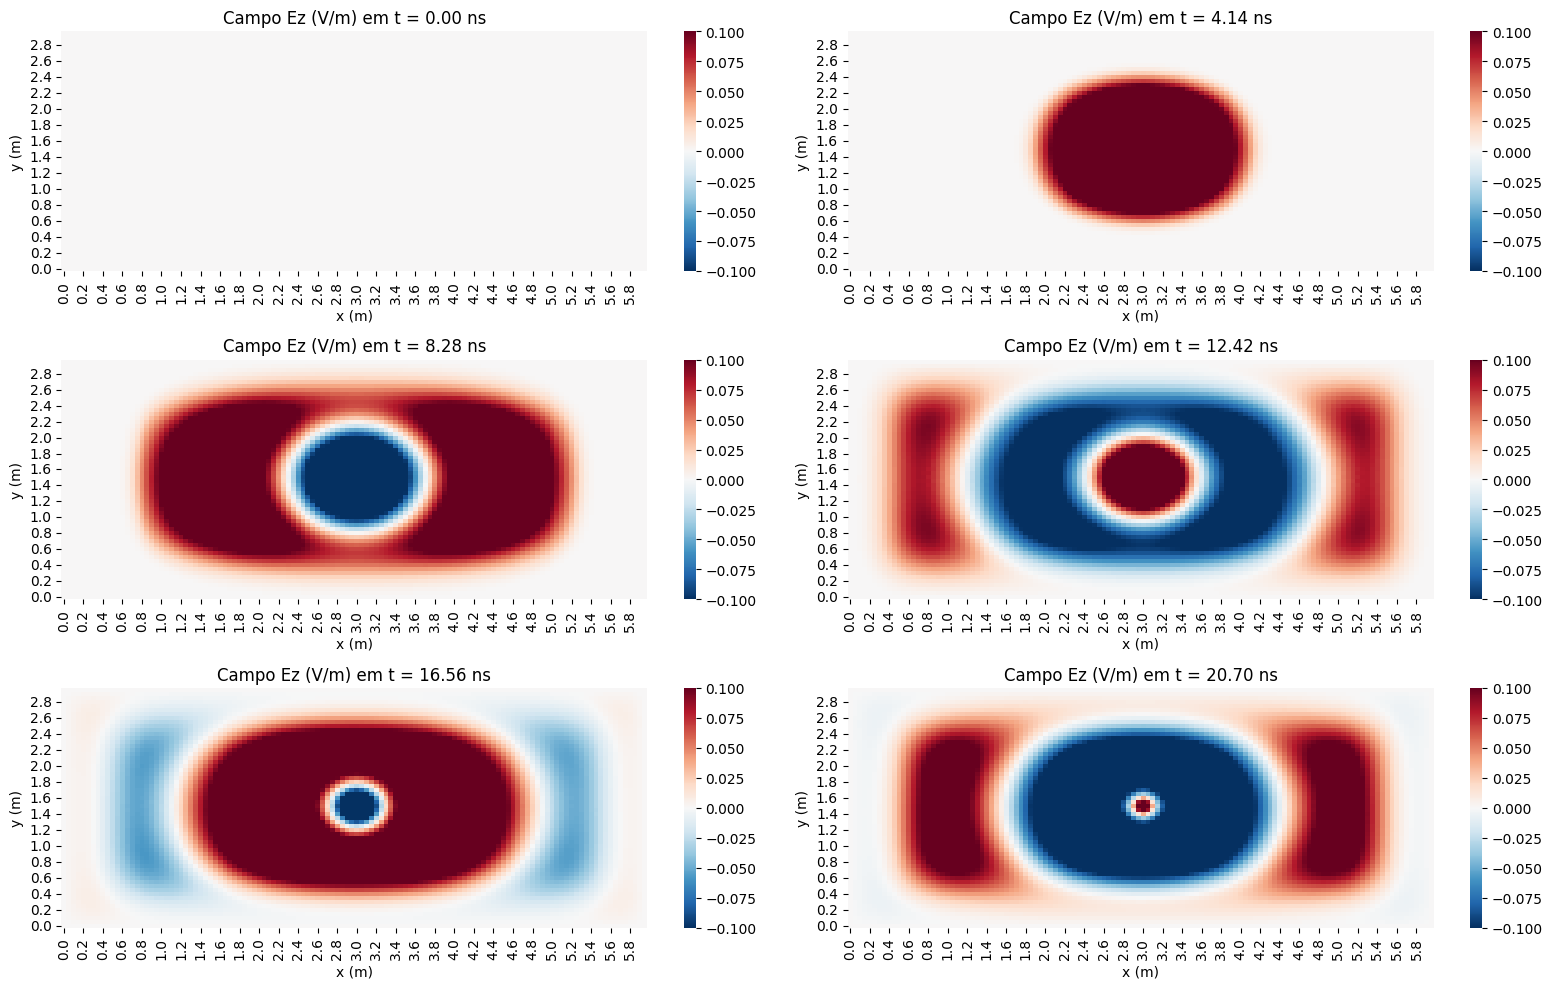

In [49]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i].T, ax=ax, annot=False, cmap='RdBu_r',vmax=0.1,vmin=-0.1,center=0)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1:.1f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1:.1f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

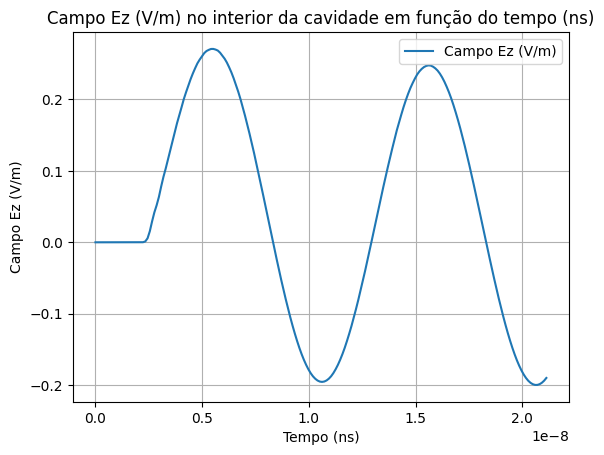

In [50]:
# plt.plot(grid_t_Ez[Nt//2:-2] * 1e9, probe[Nt//2:], label="Campo Ez (V/m)")
plt.plot(grid_t_Ez[:-1], probe[:], label="Campo Ez (V/m)")
plt.title(fr"Campo Ez (V/m) no interior da cavidade em função do tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

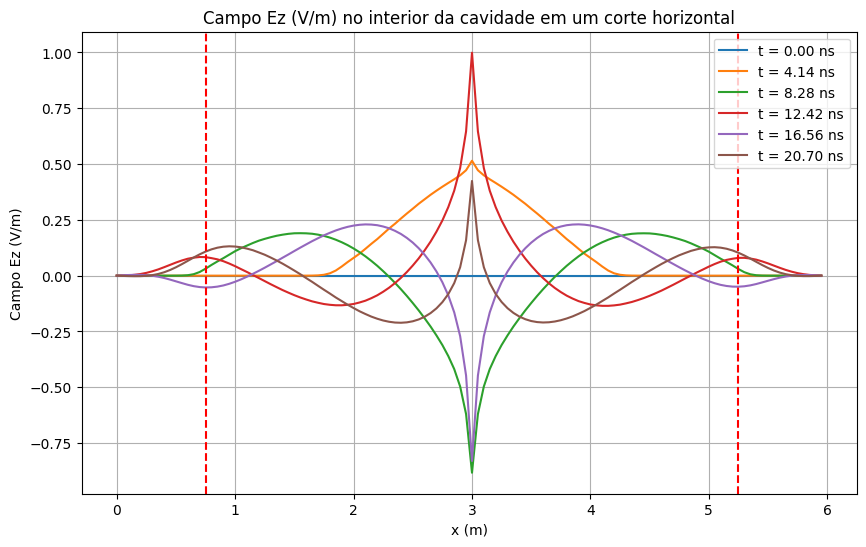

In [51]:
plt.figure(figsize=(10, 6))
plt.title(fr"Campo Ez (V/m) no interior da cavidade em um corte horizontal")
for n in range(len(Ez_snapshots)):
    plt.plot(grid_x_Ez[:-1], Ez_snapshots[n][:, Ny//2], label=f"t = {n_snapshots[n] * dt * 1e9:.2f} ns")
plt.axvline(x=(npml//2)*dx, color='r', linestyle='--')
plt.axvline(x=(Nx - (npml//2))*dx, color='r', linestyle='--')
plt.xlabel("x (m)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

In [52]:
# --- domínio ---
frequency = 100e6 # frequencia da fonte
min_lambda = vp / frequency
Nx = 1200
Ny = 600
# dx = dy = 0.1 * min_lambda       
dx = dy = 5e-2  
dt = 0.9 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 200         
L = Nx * dx
T = Nt * dt

# Declara os campos
Ez = np.zeros((Nx, Ny))
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

# PML
sigma_x = np.zeros((Nx, Ny))
sigma_y = np.zeros((Nx, Ny))
kappa_x = np.ones((Nx,Ny))
kappa_y = np.ones((Nx,Ny))

npml = 20
m = 3.75    
sigma_max = -((m+1)*np.log(1e-8))/(2*npml*dx*377)
kappa_max = 8
for i in range(npml):
    sx = sigma_max*((npml-i)/npml)**m
    sigma_x[i,:] = sx
    sigma_x[Nx-1-i,:] = sx
    kappa_x[i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
    kappa_x[Nx-1-i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
for j in range(npml):
    sy = sigma_max*((npml-j)/npml)**m
    sigma_y[:,j] = sy
    sigma_y[:,Ny-1-j] = sy
    kappa_y[:,j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m
    kappa_y[:,Ny-1-j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m

# Coeficientes da PML
sigma_e = sigma_x + sigma_y
kappa = kappa_x*kappa_y
bx = (1-((sigma_x*dt)/(2*eps*kappa_x)))/(1+((sigma_x*dt)/(2*eps*kappa_x)))
by = (1-((sigma_y*dt)/(2*eps*kappa_y)))/(1+((sigma_y*dt)/(2*eps*kappa_y)))
bz = (1-((sigma_e*dt)/(2*eps*kappa)))/(1+((sigma_e*dt)/(2*eps*kappa)))
cx = (dt/kappa_x)/(mu*dx*(1+((sigma_x*dt)/(2*eps*kappa_x))))
cy = (dt/kappa_y)/(mu*dx*(1+((sigma_y*dt)/(2*eps*kappa_y))))
cz = (dt/eps)/(1+((sigma_e*dt)/(2*eps*kappa)))

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(0, Nt - 5, 6, dtype=int)
Ez_inc_napshots = []

# ponta de prova
px, py = Nx // 2 + 10, Ny // 2 + 10
probe_inc = []

for n in range(Nt):
    # atualiza os campos
    Hx[:,:-1] = by[:,:-1]*Hx[:,:-1] - cy[:,:-1]*(Ez[:,1:]-Ez[:,:-1])
    Hy[:-1,:] = bx[:-1,:]*Hy[:-1,:] + cx[:-1,:]* (Ez[1:,:] - Ez[:-1,:])
    Ez[1:-1,1:-1] = bz[1:-1,1:-1]*Ez[1:-1,1:-1] + cz[1:-1,1:-1]*((Hy[1:-1,1:-1] - Hy[:-2,1:-1])/dx -(Hx[1:-1,1:-1] - Hx[1:-1,:-2])/dy)
    
    # fonte
    Ez[Nx//2,Ny//2] = np.sin(2*np.pi*frequency*n*dt)

    # ponta de prova
    probe_inc.append(Ez[px, py]) 

    # salva para os snapshots
    if n in n_snapshots:
        Ez_inc_napshots.append(Ez.copy())
    

In [53]:
# FFT das duas probes
probe_ez_ref = np.array(probe) - np.array(probe_inc)

fft_ref = np.fft.fft(probe_ez_ref)
fft_inc = np.fft.fft(probe_inc)

R = np.abs(fft_ref) / np.abs(fft_inc)

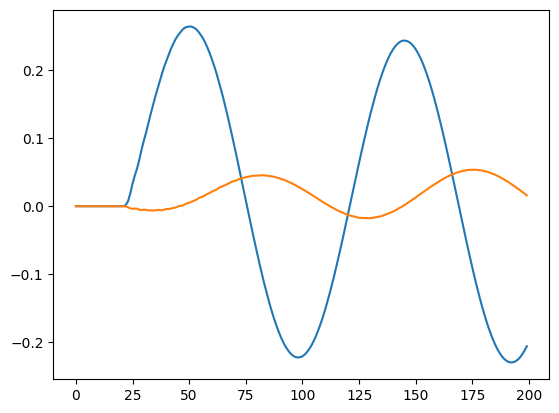

In [54]:
plt.plot(probe_inc)
plt.plot(probe_ez_ref)

In [55]:
R_list = []
for i in range(len(probe)):
    if np.abs(probe_inc[i]) < 1e-6:  # Evita divisão por zero
        continue
    R_list.append(np.abs(probe_ez_ref[i]) / np.abs(probe_inc[i]))

In [56]:
np.mean(20 * np.log10(R_list))

np.float64(-17.74405294727939)

In [57]:
sigma_max

np.float64(0.11604540256468666)